### The aim is to predict whether a telecom customer is likely to churn based on customer details and the dataset provided.Here i have used to dataset customer_churn.csv from 

##### Target Varialble = 'Churn'
##### Churn = 0 represents customers who did not churn.
##### Churn = 1 represents customers who churned.


##### Importing libraries and loading the dataset 


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow import keras

%matplotlib inline

df = pd.read_csv("/home/dell/ML-Learning/datasets/customer_churn.csv")

df.head()

I0000 00:00:1786906726.499155    8422 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786906726.505054    8422 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786906727.102725    8422 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786906730.318382    8422 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### We will explore the dataset , its shape and columns. we will analyse it and remove the columns that are not needed and do data cleaning 


In [3]:
print(df.shape)
print(df.info())

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


##### The dataset contains coulmns like customer id , partner , tenure , phone services payment method etc, in this case we will only focus on the columns necessary to ananlyse the churn . 

In [4]:
df.drop('customerID', axis=1, inplace=True)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### CustomerID acts like a primary key , so I removed it because it does not provide useful information for predicting churn.

In [5]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].unique()[:20])

str
<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str


#### TotalCharges had blank values. I converted the whole column to numeric and let invalid values become NaN.

In [6]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("Missing values in TotalCharges:", df['TotalCharges'].isnull().sum())

Missing values in TotalCharges: 11


In [7]:
df1 = df.dropna(subset=['TotalCharges']).copy()

df1.shape

(7032, 20)

In [8]:
df1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [9]:
df1.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [10]:
df1.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

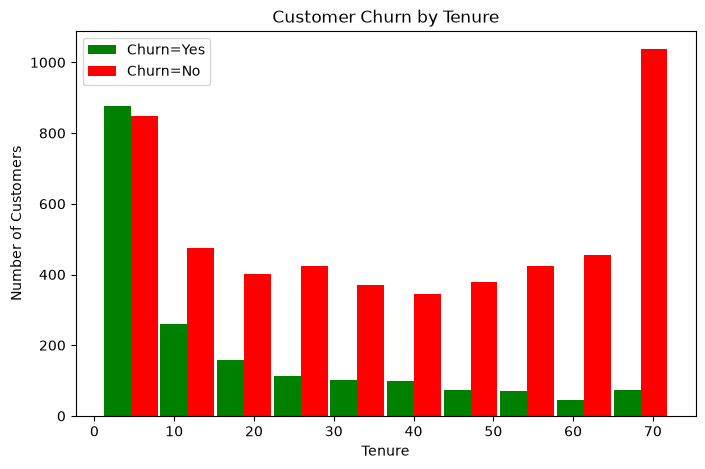

In [11]:
tenure_churn_no = df1[df1['Churn'] == 'No']['tenure']
tenure_churn_yes = df1[df1['Churn'] == 'Yes']['tenure']

plt.figure(figsize=(8, 5))

plt.xlabel('Tenure')
plt.ylabel('Number of Customers')
plt.title('Customer Churn by Tenure')

plt.hist([tenure_churn_yes, tenure_churn_no], rwidth=0.95, color=['green','red'],label=['Churn=Yes','Churn=No'])


plt.legend()

plt.show()

##### Customers with lower tenure might have a higher proportion of churn, while customers who have stayed longer are more likely to remain.

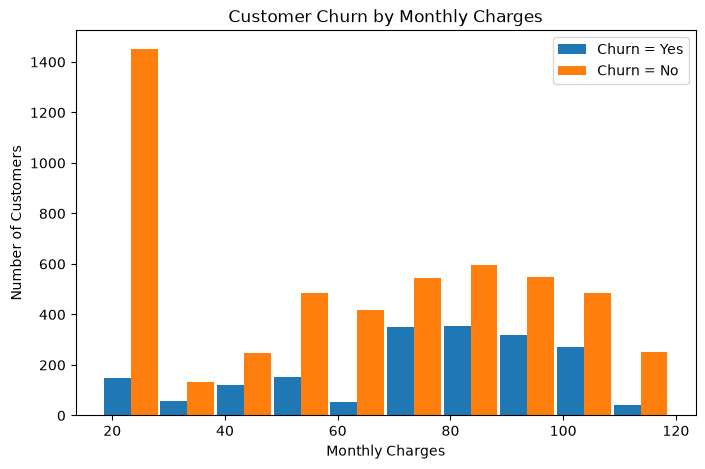

In [12]:
mc_churn_no = df1[df1['Churn'] == 'No']['MonthlyCharges']
mc_churn_yes = df1[df1['Churn'] == 'Yes']['MonthlyCharges']

plt.figure(figsize=(8, 5))

plt.hist(
    [mc_churn_yes, mc_churn_no],
    rwidth=0.95,
    label=['Churn = Yes', 'Churn = No']
)

plt.xlabel('Monthly Charges')
plt.ylabel('Number of Customers')
plt.title('Customer Churn by Monthly Charges')
plt.legend()

plt.show()

##### Customers with higher monthly charges are more often in the churn group. 

In [13]:
def print_unique_col_values(df):
    for column in df:
        if df[column].dtype == 'object':
            print(f'{column}: {df[column].unique()}')

print_unique_col_values(df1)

In [14]:
def print_unique_col_values(df):
       for column in df:
            if df[column].dtypes=='object':
                print(f'{column}: {df[column].unique()}') 
df1.replace('No internet service', 'No', inplace=True)
df1.replace('No phone service', 'No', inplace=True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [15]:
yes_no_columns = [
    'Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport','StreamingTV','StreamingMovies','PaperlessBilling'
]

for col in yes_no_columns:
    df1[col] = df1[col].map({
        'Yes': 1,
        'No': 0
    })

df1['gender'] = df1['gender'].map({
    'Female': 1,
    'Male': 0
})

df1['Churn'] = df1['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [16]:
print(df1['gender'].unique())
print(df1['Churn'].unique())

[1 0]
[0 1]


##### categorical variables were converted into 0 and 1 so that they can be used by the machine learning models. 

In [ ]:
df2 = pd.get_dummies(
    df1,
    columns=[
        'InternetService', 'Contract', 'PaymentMethod'
    ]
)

##### Used one hot encoding to convert variables that are not binary categorical variables , they have more that 2 variables . 

In [18]:
bool_columns = df2.select_dtypes(include='bool').columns

df2[bool_columns] = df2[bool_columns].astype(int)

In [19]:
print(df2.shape)


print(df2.isnull().sum().sum())


(7032, 27)
0


In [20]:

print(df2.select_dtypes(include='object').columns)

Index([], dtype='str')


In [21]:
for col in df2:
    print(f'{col}: {df2[col].unique()[:10]}')

gender: [1 0]
SeniorCitizen: [0 1]
Partner: [1 0]
Dependents: [0 1]
tenure: [ 1 34  2 45  8 22 10 28 62 13]
PhoneService: [0 1]
MultipleLines: [0 1]
OnlineSecurity: [0 1]
OnlineBackup: [1 0]
DeviceProtection: [0 1]
TechSupport: [0 1]
StreamingTV: [0 1]
StreamingMovies: [0 1]
PaperlessBilling: [1 0]
MonthlyCharges: [ 29.85  56.95  53.85  42.3   70.7   99.65  89.1   29.75 104.8   56.15]
TotalCharges: [  29.85 1889.5   108.15 1840.75  151.65  820.5  1949.4   301.9  3046.05
 3487.95]
Churn: [0 1]
InternetService_DSL: [1 0]
InternetService_Fiber optic: [0 1]
InternetService_No: [0 1]
Contract_Month-to-month: [1 0]
Contract_One year: [0 1]
Contract_Two year: [0 1]
PaymentMethod_Bank transfer (automatic): [0 1]
PaymentMethod_Credit card (automatic): [0 1]
PaymentMethod_Electronic check: [1 0]
PaymentMethod_Mailed check: [0 1]


##### Used to understand the types of variables each column hold and verify if one hot encoding worked 

In [22]:
X = df2.drop('Churn', axis=1)

y = df2['Churn']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 26)
y shape: (7032,)


##### X contains the input features and y contains the target variable.

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5625, 26)
X_test: (1407, 26)
y_train: (5625,)
y_test: (1407,)


##### Spliting the test train data 

In [24]:
cols_to_scale = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges'
]

scaler = MinMaxScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[cols_to_scale] = scaler.fit_transform(
    X_train[cols_to_scale]
)

X_test[cols_to_scale] = scaler.transform(
    X_test[cols_to_scale]
)

##### MinMaxScaler converts values to a range 0 and 1 . TotalCharges has values that are much larger than tenure or MonthlyCharges and this larger numerical ranges can have a disproportionate influence. Therefore we do scaling. 

In [25]:
print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test:", X_test.isnull().sum().sum())

print("\nTraining target values:", y_train.unique())
print("Testing target values:", y_test.unique())

print("\nData types:")
print(X_train.dtypes)

Missing values in X_train: 0
Missing values in X_test: 0

Training target values: [1 0]
Testing target values: [0 1]

Data types:
gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                     float64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
InternetService_DSL                          int64
Int

In [26]:
X_train_ann = X_train.to_numpy(dtype='float32')
X_test_ann = X_test.to_numpy(dtype='float32')

y_train_ann = y_train.to_numpy(dtype='float32')
y_test_ann = y_test.to_numpy(dtype='float32')

In [27]:
np.random.seed(42)
tf.random.set_seed(42)

##### I fixed the random seed so that the model gives similar results when the notebook runs again.

In [28]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train_ann.shape[1],)),
    keras.layers.Dense(26, activation='relu'),
    keras.layers.Dense(15, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.summary()

E0000 00:00:1786909584.605992    8422 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 26)             │           702 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           405 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,123 (4.39 KB)

 Trainable params: 1,123 (4.39 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

##### I used a small neural network with two hidden layers. ReLU is used in the hidden layers and sigmoid is used in the output layer because this is a binary classification problem.

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

#### Stop training when the validation loss stops improving

In [31]:
history = model.fit(
    X_train_ann,
    y_train_ann,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7471 - loss: 0.5058 - val_accuracy: 0.7644 - val_loss: 0.4490
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7973 - loss: 0.4280 - val_accuracy: 0.7778 - val_loss: 0.4390
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8031 - loss: 0.4194 - val_accuracy: 0.7804 - val_loss: 0.4364
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8053 - loss: 0.4150 - val_accuracy: 0.7822 - val_loss: 0.4345
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8067 - loss: 0.4120 - val_accuracy: 0.7831 - val_loss: 0.4330
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8071 - loss: 0.4099 - val_accuracy: 0.7876 - val_loss: 0.4320
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8082 - loss: 0.4084 - val_accuracy: 0.7867 - val_loss: 0.4312
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8100 - loss: 0.4070 - val_accu

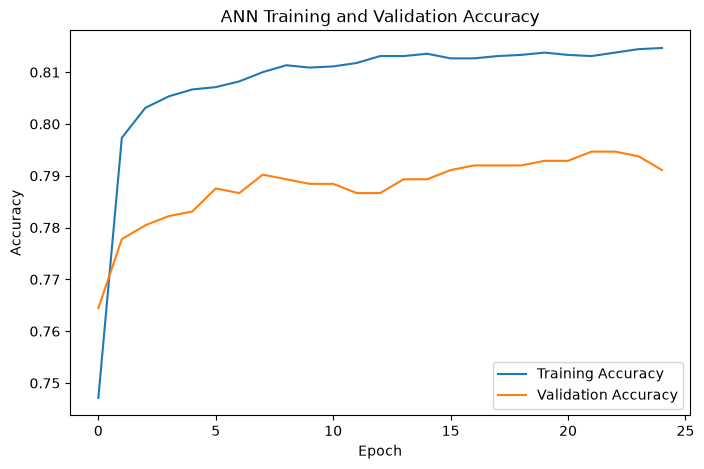

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('ANN Training and Validation Accuracy')
plt.legend()

plt.show()

##### Compare training and validation accuracy during training

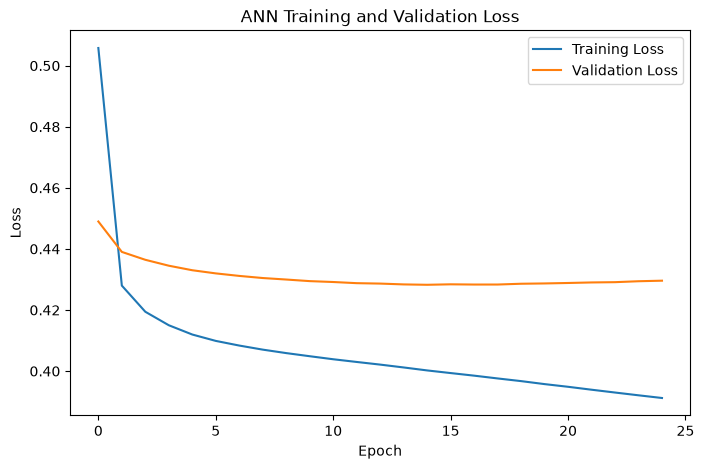

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ANN Training and Validation Loss')
plt.legend()

plt.show()

##### Check how the training and validation loss changed

In [34]:
ann_loss, ann_accuracy = model.evaluate(
    X_test_ann,
    y_test_ann,
    verbose=0
)

print("ANN Test Accuracy:", ann_accuracy)
print("ANN Test Loss:", ann_loss)

ANN Test Accuracy: 0.7867803573608398
ANN Test Loss: 0.4424605071544647


In [35]:
y_prob_ann = model.predict(
    X_test_ann,
    verbose=0
).ravel()

y_pred_ann = (y_prob_ann >= 0.5).astype(int)

##### Get churn probabilities and convert them into 0 or 1 predictions

In [36]:
print(y_pred_ann[:10])
print(y_prob_ann[:10])

[0 0 0 1 1 1 0 1 0 0]
[0.19269162 0.30964866 0.01132211 0.72777784 0.5006994  0.6684338
 0.09645337 0.6686455  0.4016553  0.18979494]


In [37]:
print(classification_report(
    y_test_ann,
    y_pred_ann,
    target_names=['No Churn', 'Churn']
))

              precision    recall  f1-score   support

    No Churn       0.82      0.90      0.86       999
       Churn       0.67      0.51      0.58       408

    accuracy                           0.79      1407
   macro avg       0.75      0.71      0.72      1407
weighted avg       0.78      0.79      0.78      1407



[[898 101]
 [199 209]]


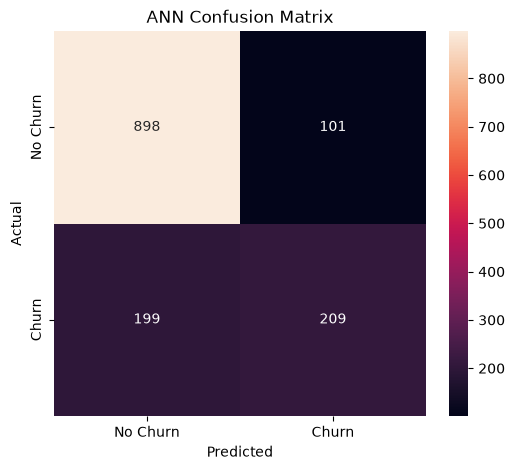

In [38]:
cm_ann = confusion_matrix(
    y_test_ann,
    y_pred_ann
)

print(cm_ann)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_ann,
    annot=True,
    fmt='d',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ANN Confusion Matrix')

plt.show()

In [39]:
tn, fp, fn, tp = cm_ann.ravel()

ann_specificity = tn / (tn + fp)
ann_fpr = fp / (fp + tn)
ann_fnr = fn / (fn + tp)

ann_results = {
    'Model': 'ANN',
    'Accuracy': accuracy_score(y_test_ann, y_pred_ann),
    'Precision': precision_score(y_test_ann, y_pred_ann),
    'Recall': recall_score(y_test_ann, y_pred_ann),
    'Specificity': ann_specificity,
    'F1 Score': f1_score(y_test_ann, y_pred_ann),
    'Balanced Accuracy': balanced_accuracy_score(
        y_test_ann,
        y_pred_ann
    ),
    'ROC-AUC': roc_auc_score(
        y_test_ann,
        y_prob_ann
    ),
    'PR-AUC': average_precision_score(
        y_test_ann,
        y_prob_ann
    ),
    'Log Loss': log_loss(
        y_test_ann,
        y_prob_ann
    ),
    'Brier Score': brier_score_loss(
        y_test_ann,
        y_prob_ann
    ),
    'False Positive Rate': ann_fpr,
    'False Negative Rate': ann_fnr
}

print(ann_results)

{'Model': 'ANN', 'Accuracy': 0.7867803837953091, 'Precision': 0.6741935483870968, 'Recall': 0.5122549019607843, 'Specificity': np.float64(0.8988988988988988), 'F1 Score': 0.5821727019498607, 'Balanced Accuracy': 0.7055769004298416, 'ROC-AUC': 0.8381960391764315, 'PR-AUC': 0.6390158332788425, 'Log Loss': 0.4424605369567871, 'Brier Score': 0.14612412452697754, 'False Positive Rate': np.float64(0.1011011011011011), 'False Negative Rate': np.float64(0.4877450980392157)}


##### Calculate different metrics to evaluate the ANN

In [40]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

##### Train Logistic Regression as a simpler model for comparison

In [41]:
y_pred_lr = logistic_model.predict(X_test)

y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

##### Check the classification performance of Logistic Regression

In [42]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['No Churn', 'Churn']
))

              precision    recall  f1-score   support

    No Churn       0.83      0.89      0.86       999
       Churn       0.67      0.55      0.61       408

    accuracy                           0.79      1407
   macro avg       0.75      0.72      0.73      1407
weighted avg       0.79      0.79      0.79      1407



[[890 109]
 [182 226]]


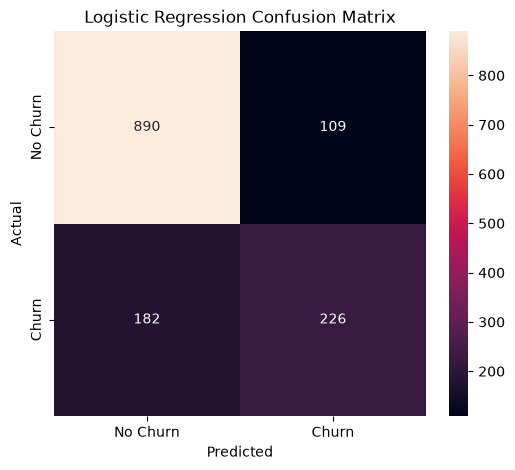

In [43]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Logistic Regression Confusion Matrix')

plt.show()

In [44]:
tn, fp, fn, tp = cm_lr.ravel()

lr_specificity = tn / (tn + fp)
lr_fpr = fp / (fp + tn)
lr_fnr = fn / (fn + tp)

lr_results = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_lr),
    'Precision': precision_score(y_test, y_pred_lr),
    'Recall': recall_score(y_test, y_pred_lr),
    'Specificity': lr_specificity,
    'F1 Score': f1_score(y_test, y_pred_lr),
    'Balanced Accuracy': balanced_accuracy_score(
        y_test,
        y_pred_lr
    ),
    'ROC-AUC': roc_auc_score(
        y_test,
        y_prob_lr
    ),
    'PR-AUC': average_precision_score(
        y_test,
        y_prob_lr
    ),
    'Log Loss': log_loss(
        y_test,
        y_prob_lr
    ),
    'Brier Score': brier_score_loss(
        y_test,
        y_prob_lr
    ),
    'False Positive Rate': lr_fpr,
    'False Negative Rate': lr_fnr
}

print(lr_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.7931769722814499, 'Precision': 0.6746268656716418, 'Recall': 0.553921568627451, 'Specificity': np.float64(0.8908908908908909), 'F1 Score': 0.6083445491251682, 'Balanced Accuracy': 0.7224062297591709, 'ROC-AUC': 0.8412407505544762, 'PR-AUC': 0.6438519977654201, 'Log Loss': 0.43820373582871824, 'Brier Score': 0.14334572581933236, 'False Positive Rate': np.float64(0.1091091091091091), 'False Negative Rate': np.float64(0.44607843137254904)}


##### ROC curve evaluates the model across different probability thresholds. 

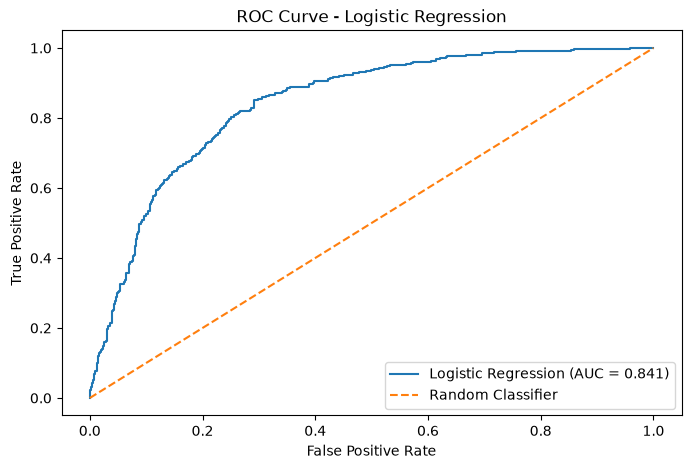

In [45]:
fpr_lr, tpr_lr, thresholds_lr = roc_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {lr_results["ROC-AUC"]:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()

plt.show()

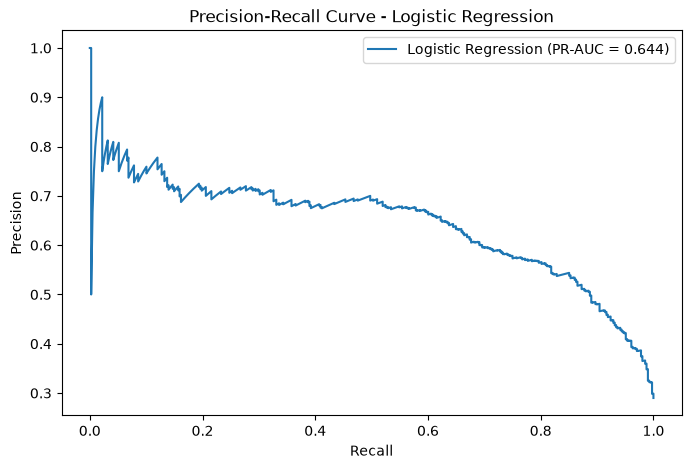

In [46]:
precision_lr, recall_lr, thresholds_pr_lr = precision_recall_curve(
    y_test,
    y_prob_lr
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall_lr,
    precision_lr,
    label=f'Logistic Regression (PR-AUC = {lr_results["PR-AUC"]:.3f})'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Logistic Regression')
plt.legend()

plt.show()

##### The ROC curve gives an AUC of 0.841, indicating that Logistic Regression has good ability to distinguish between churn and non-churn customers. The curve stays well above the random classifier line, showing that the model performs better than random classification.

In [47]:
comparison = pd.DataFrame([
    ann_results,
    lr_results
])

comparison.round(4)

,Model,Accuracy,Precision,Recall,Specificity,F1 Score,Balanced Accuracy,ROC-AUC,PR-AUC,Log Loss,Brier Score,False Positive Rate,False Negative Rate
0,ANN,0.7868,0.6742,0.5123,0.8989,0.5822,0.7056,0.8382,0.6390,0.4425,0.1461,0.1011,0.4877
1,Logistic Regression,0.7932,0.6746,0.5539,0.8909,0.6083,0.7224,0.8412,0.6439,0.4382,0.1433,0.1091,0.4461


In [48]:
comparison[
    [
        'Model',
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'Specificity',
        'ROC-AUC'
    ]
].round(4)

,Model,Accuracy,Precision,Recall,F1 Score,Specificity,ROC-AUC
0,ANN,0.7868,0.6742,0.5123,0.5822,0.8989,0.8382
1,Logistic Regression,0.7932,0.6746,0.5539,0.6083,0.8909,0.8412


##### Compared the accuracy precision recall F1 score , Specidicity and ROC - AUC curve 